In [1]:
from src.baseline_config import build_training_config
from src.phase3.config import PHASE3_FILTER_PARAMS, PHASE3_SSIM_THRESHOLD, PHASE3_PHASH_THRESHOLD
from src.phase3.experiment import (
    PHASE3_SOURCE_CSV,
    print_phase3_dataset_summary,
    print_phase3_summary,
    run_phase3_processing,
    show_phase3_plots,
    train_phase3_dataset,
)

TRAINING_CONFIG = build_training_config(architecture="efficientnet_b0")


In [2]:
print_phase3_dataset_summary(PHASE3_SOURCE_CSV)

Rows: 7978
histology
Adenoma                     2850
Sessile_serrated_adenoma    2554
Hyperplastic                1613
Adenocarcinoma               961


In [3]:
phase3_steps = {
    "deduplication": True,
    "darkness": False,
    "uniformity": False,
    "blur": False,
}

phase3_result = run_phase3_processing(
    steps=phase3_steps,
    input_csv=PHASE3_SOURCE_CSV,
    params=PHASE3_FILTER_PARAMS,
    ssim_threshold=PHASE3_SSIM_THRESHOLD,
    phash_distance_threshold=PHASE3_PHASH_THRESHOLD,
)

phase3_result["output_csv"]

WindowsPath('phase3/phase3_deduplication_ssim07_phash6.csv')

In [4]:
print_phase3_dataset_summary(phase3_result["output_csv"])

Rows: 7336
histology
Adenoma                     2704
Sessile_serrated_adenoma    2343
Hyperplastic                1415
Adenocarcinoma               874


In [5]:
train_phase3_dataset(
    train_csv=phase3_result["output_csv"],
    descriptor=phase3_result["descriptor"],
    force_train=False,
    training_config=TRAINING_CONFIG,
)

Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6\seed_1\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6\seed_2\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6\seed_3\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6\seed_4\best_baseline_model.pth


'deduplication_ssim07_phash6'

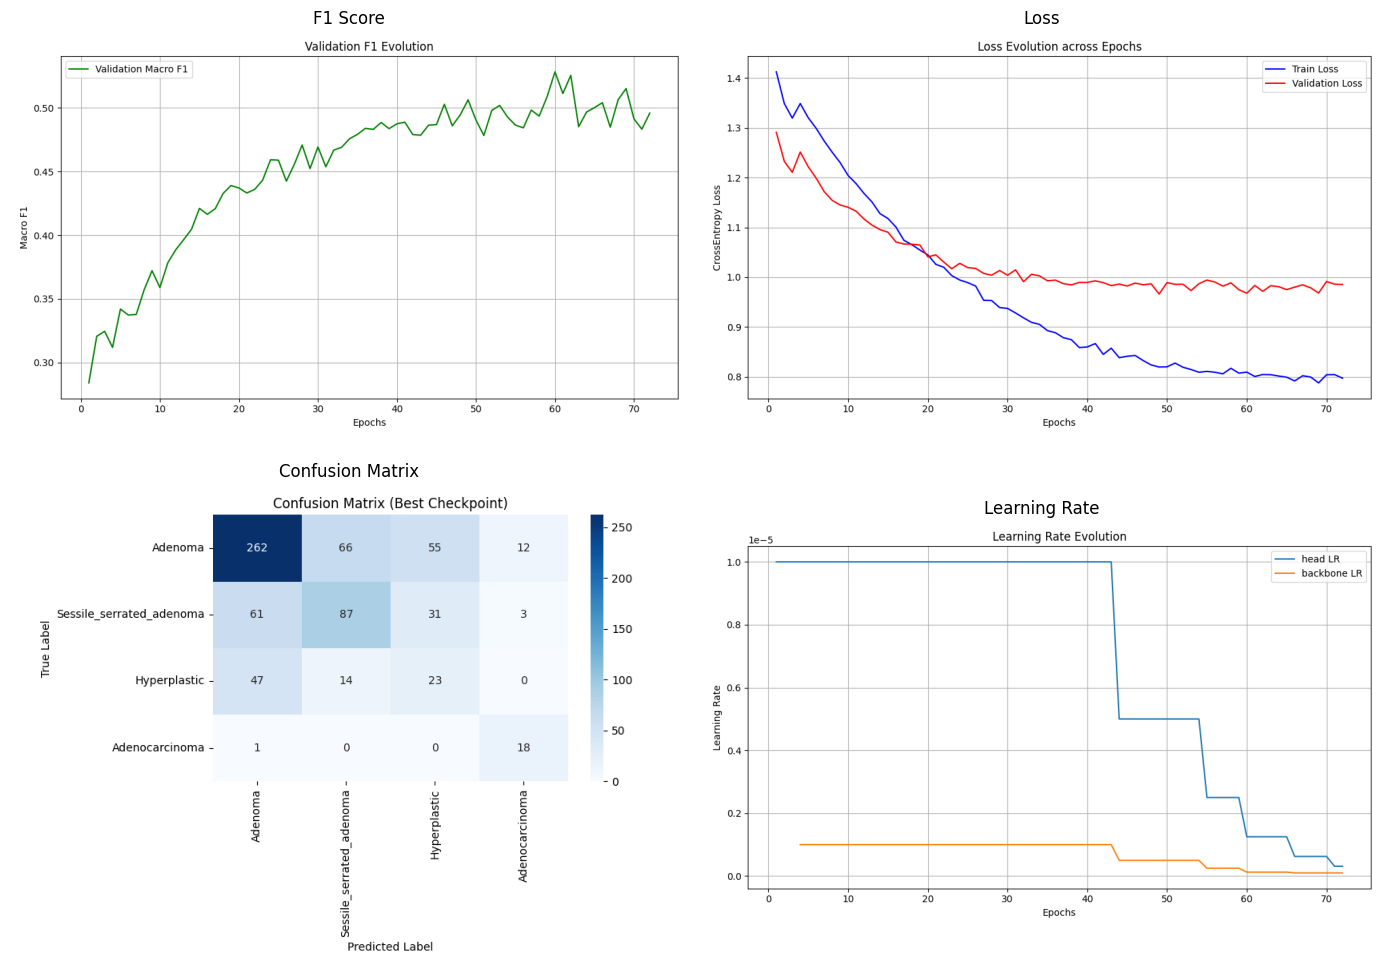

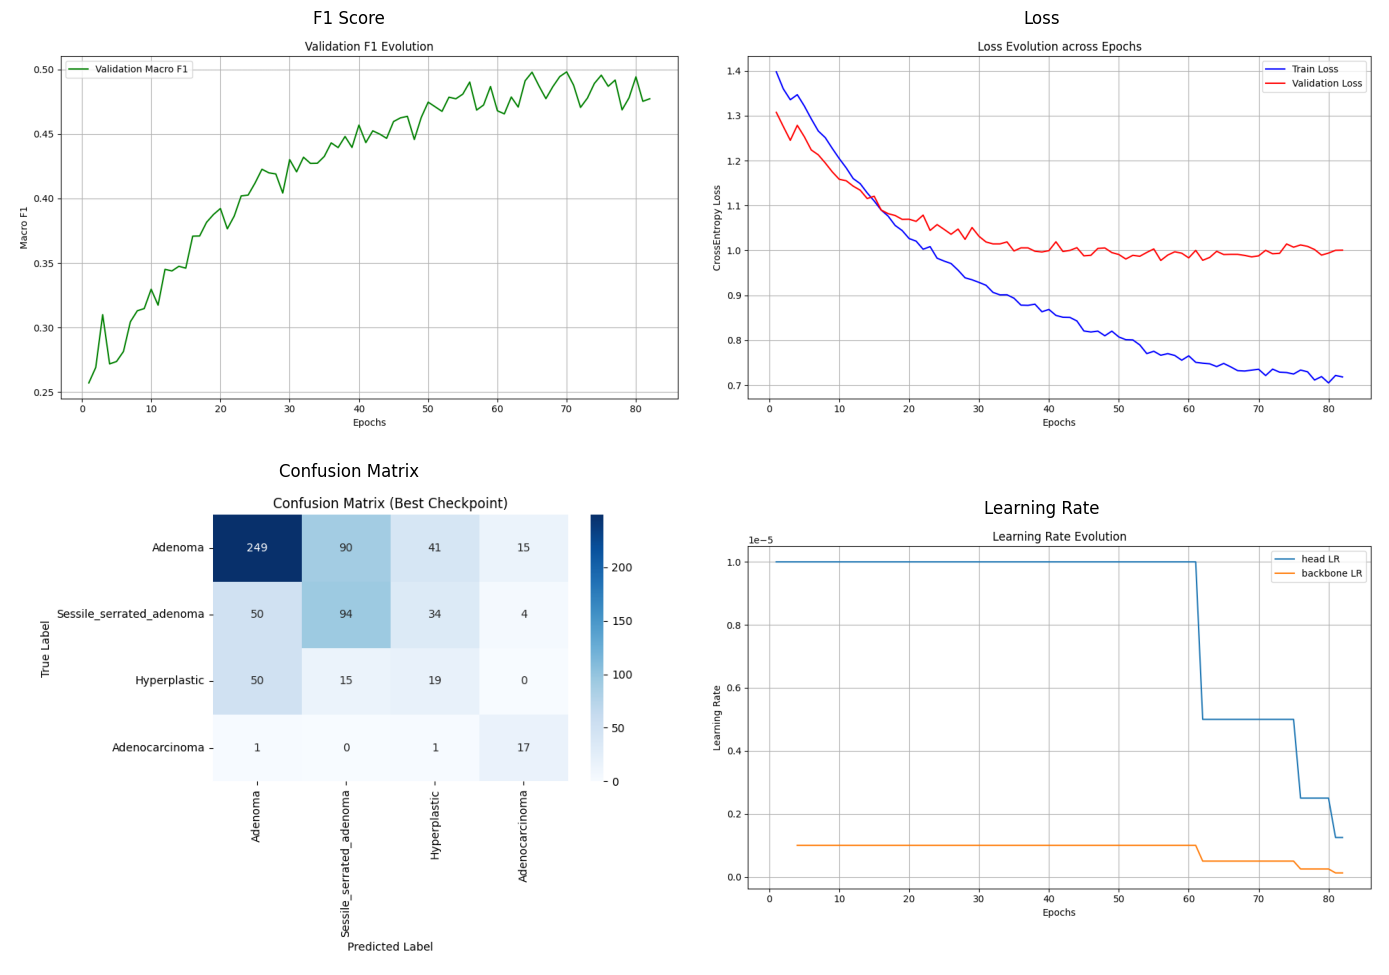

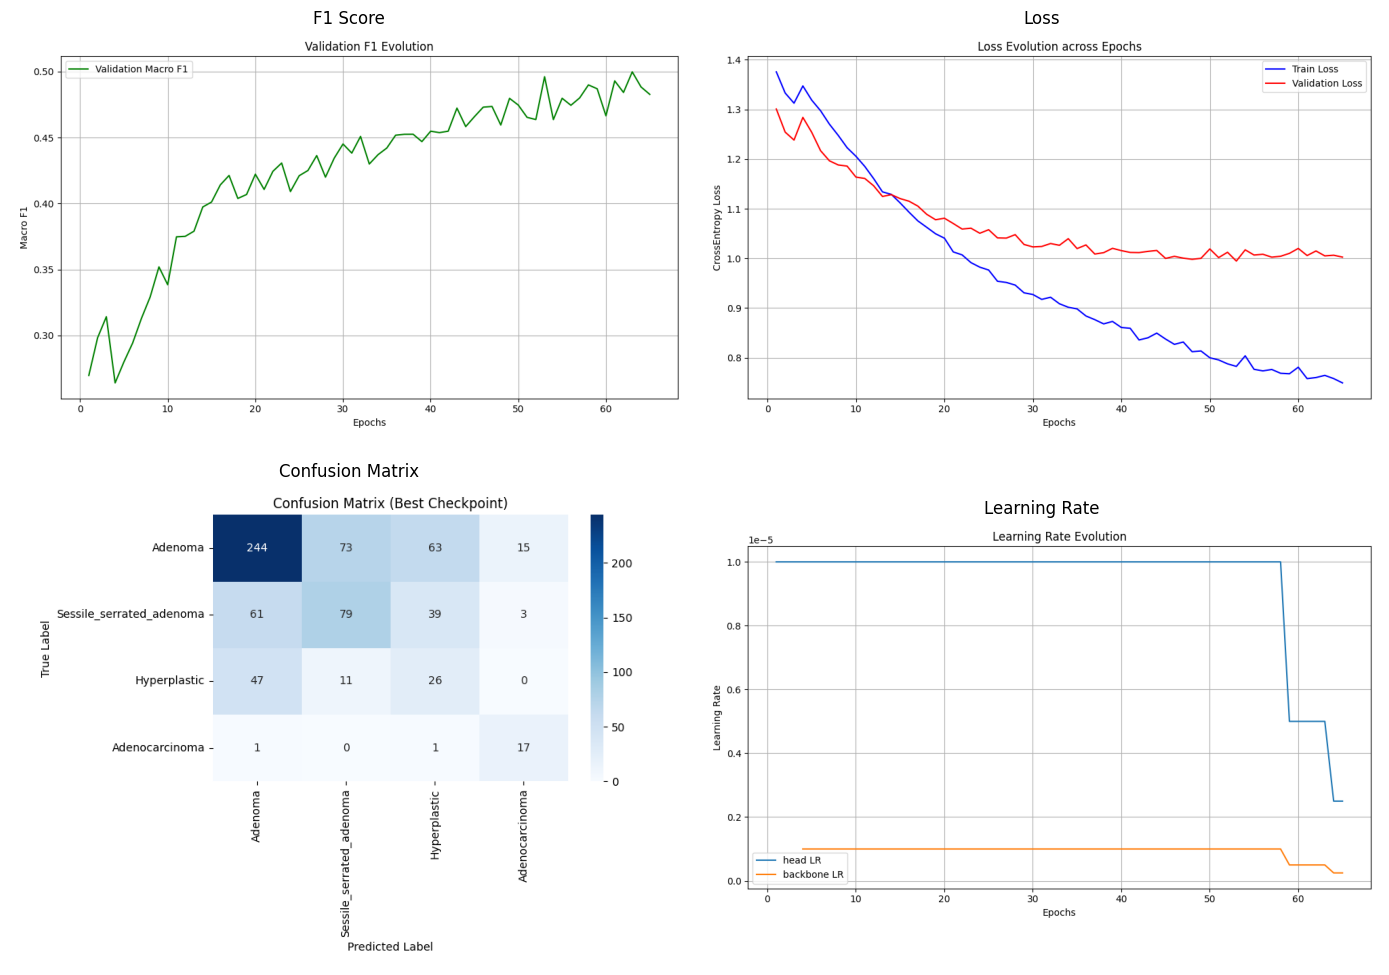

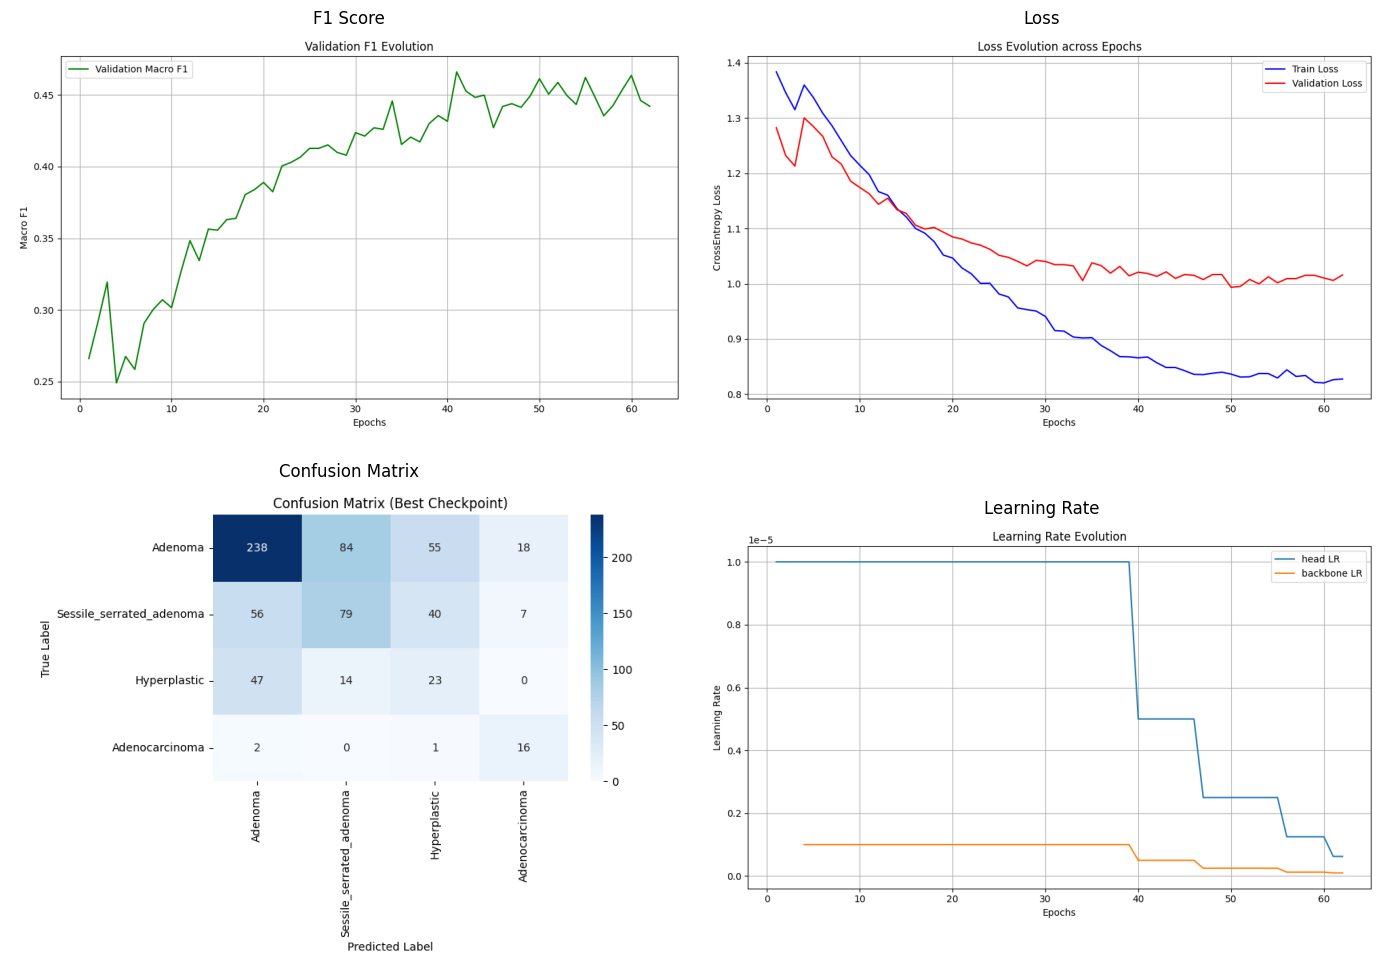

In [6]:
show_phase3_plots(
    train_csv=phase3_result["output_csv"],
    descriptor=phase3_result["descriptor"],
    training_config=TRAINING_CONFIG,
)

In [7]:
print_phase3_summary(
    train_csv=phase3_result["output_csv"],
    descriptor=phase3_result["descriptor"],
    training_config=TRAINING_CONFIG,
)

accuracy: mean=0.5482, std=0.0219
balanced_accuracy: mean=0.5649, std=0.0215
macro_f1: mean=0.4959, std=0.0274
weighted_f1: mean=0.5570, std=0.0190
Adenoma_precision: mean=0.7007, std=0.0097
Adenoma_recall: mean=0.6285, std=0.0258
Adenoma_f1-score: mean=0.6625, std=0.0174
Sessile_serrated_adenoma_precision: mean=0.4811, std=0.0310
Sessile_serrated_adenoma_recall: mean=0.4657, std=0.0397
Sessile_serrated_adenoma_f1-score: mean=0.4725, std=0.0282
Hyperplastic_precision: mean=0.2015, std=0.0073
Hyperplastic_recall: mean=0.2708, std=0.0342
Hyperplastic_f1-score: mean=0.2303, std=0.0141
Adenocarcinoma_precision: mean=0.4734, std=0.0639
Adenocarcinoma_recall: mean=0.8947, std=0.0430
Adenocarcinoma_f1-score: mean=0.6184, std=0.0654
macro_avg_precision: mean=0.4642, std=0.0265
macro_avg_recall: mean=0.5649, std=0.0215
macro_avg_f1-score: mean=0.4959, std=0.0274
weighted_avg_precision: mean=0.5739, std=0.0141
weighted_avg_recall: mean=0.5482, std=0.0219
weighted_avg_f1-score: mean=0.5570, std=0

In [8]:
phase3_steps = {
    "deduplication": True,
    "darkness": True,
    "uniformity": True,
    "blur": True,
}

phase3_result = run_phase3_processing(
    steps=phase3_steps,
    input_csv=PHASE3_SOURCE_CSV,
    params=PHASE3_FILTER_PARAMS,
    ssim_threshold=PHASE3_SSIM_THRESHOLD,
    phash_distance_threshold=PHASE3_PHASH_THRESHOLD,
)

phase3_result["output_csv"]

WindowsPath('phase3/phase3_deduplication_ssim07_phash6_darkness50_uniformity65_blur35.csv')

In [9]:
print_phase3_dataset_summary(phase3_result["output_csv"])

Rows: 6823
histology
Adenoma                     2507
Sessile_serrated_adenoma    2201
Hyperplastic                1311
Adenocarcinoma               804


In [10]:
train_phase3_dataset(
    train_csv=phase3_result["output_csv"],
    descriptor=phase3_result["descriptor"],
    force_train=False,
    training_config=TRAINING_CONFIG,
)

Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6_darkness50_uniformity65_blur35\seed_1\best_baseline_model.pth
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6_darkness50_uniformity65_blur35\seed_2


Training Progress:  32%|███▏      | 63/200 [51:19<1:51:35, 48.88s/epoch, Stage=full_network, Train Loss=0.7391, Val Loss=1.0005, Val Macro F1=0.4671, Val Score=0.5331, Best Epoch=52, LR=2.5e-07/2.5e-06]       


Early stopping triggered after 12 epochs without improving the validation score.
Optimization sequence completed with seed 123. Selected checkpoint macro-F1: 0.4805 with validation loss 0.9941 and validation score 0.5164 at epoch 52.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6_darkness50_uniformity65_blur35\seed_2'.
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6_darkness50_uniformity65_blur35\seed_3


Training Progress:  34%|███▍      | 68/200 [54:16<1:45:21, 47.89s/epoch, Stage=full_network, Train Loss=0.7248, Val Loss=1.0030, Val Macro F1=0.4801, Val Score=0.5215, Best Epoch=57, LR=2.5e-07/2.5e-06]       


Early stopping triggered after 12 epochs without improving the validation score.
Optimization sequence completed with seed 456. Selected checkpoint macro-F1: 0.5120 with validation loss 1.0113 and validation score 0.4935 at epoch 57.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6_darkness50_uniformity65_blur35\seed_3'.
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6_darkness50_uniformity65_blur35\seed_4


Training Progress:  30%|███       | 60/200 [48:17<1:52:40, 48.29s/epoch, Stage=full_network, Train Loss=0.8262, Val Loss=1.0160, Val Macro F1=0.4453, Val Score=0.5636, Best Epoch=49, LR=1.2e-07/1.3e-06]       


Early stopping triggered after 12 epochs without improving the validation score.
Optimization sequence completed with seed 789. Selected checkpoint macro-F1: 0.4523 with validation loss 1.0024 and validation score 0.5490 at epoch 49.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\deduplication_ssim07_phash6_darkness50_uniformity65_blur35\seed_4'.


'deduplication_ssim07_phash6_darkness50_uniformity65_blur35'

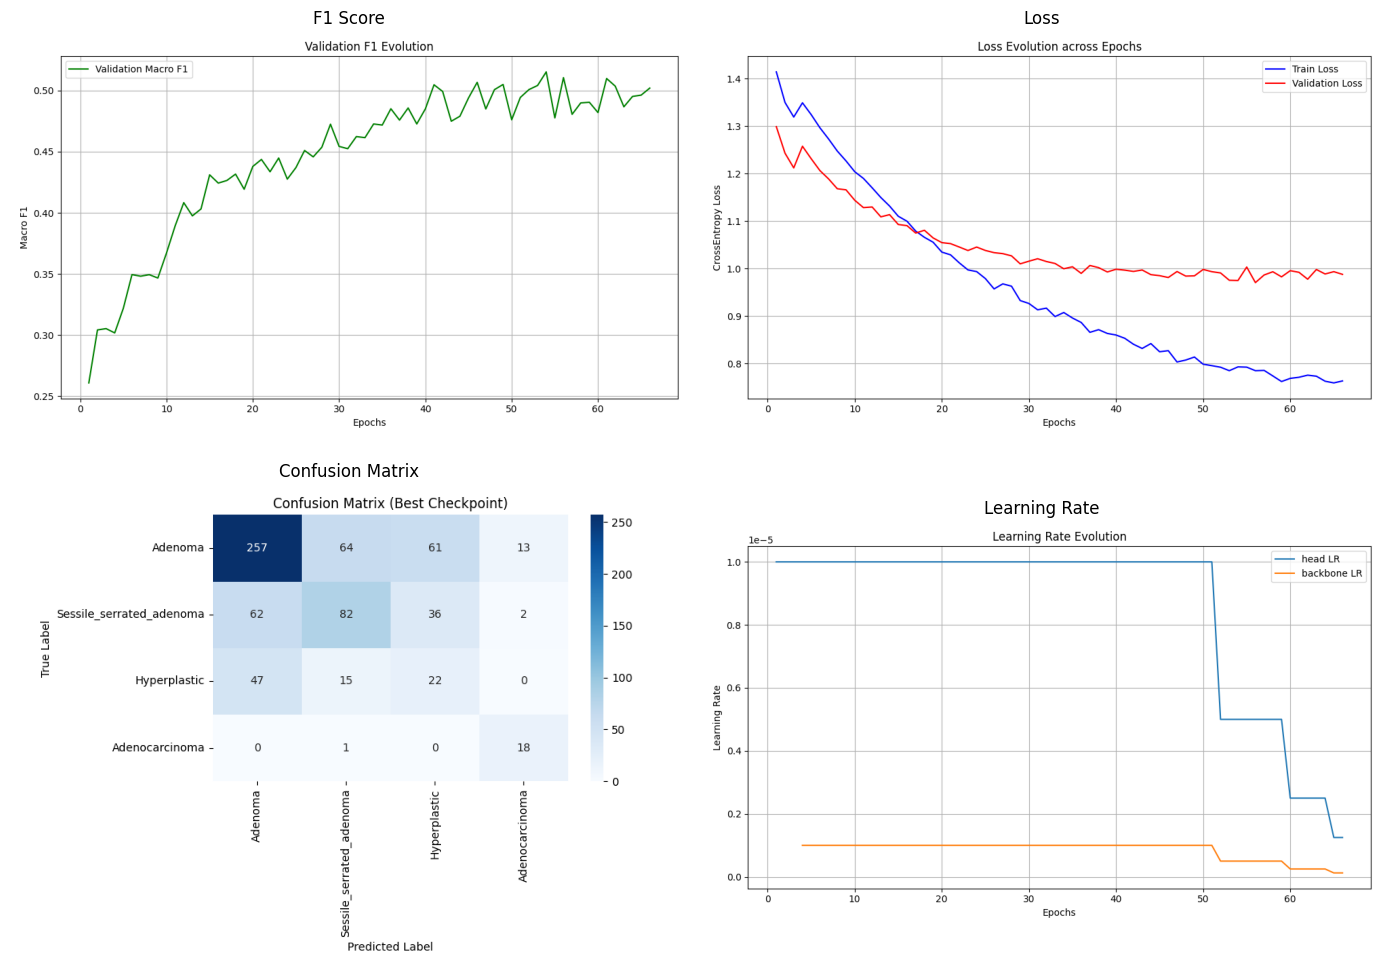

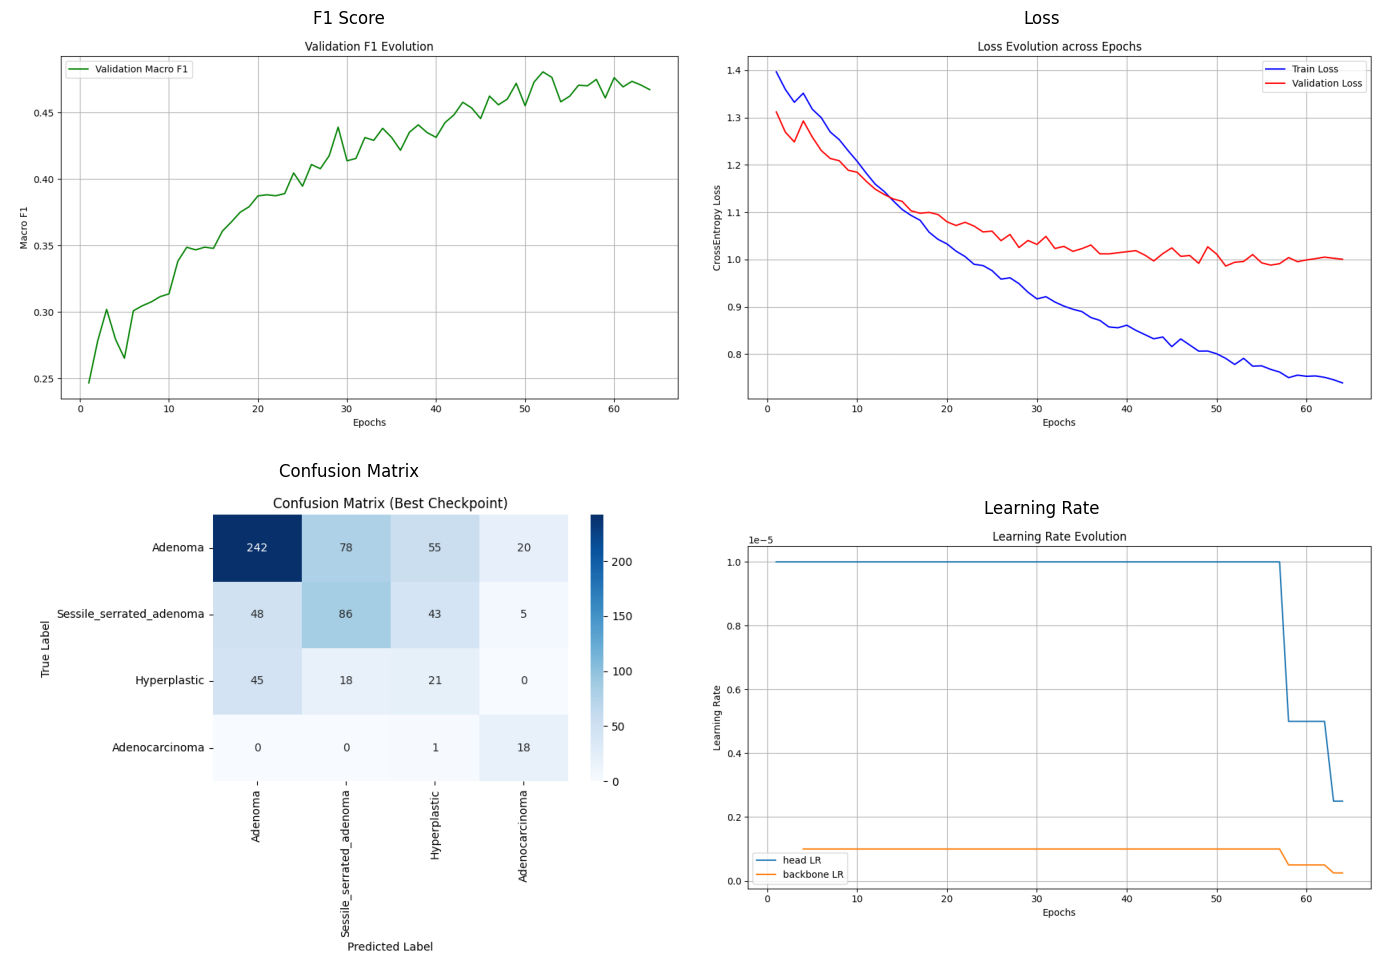

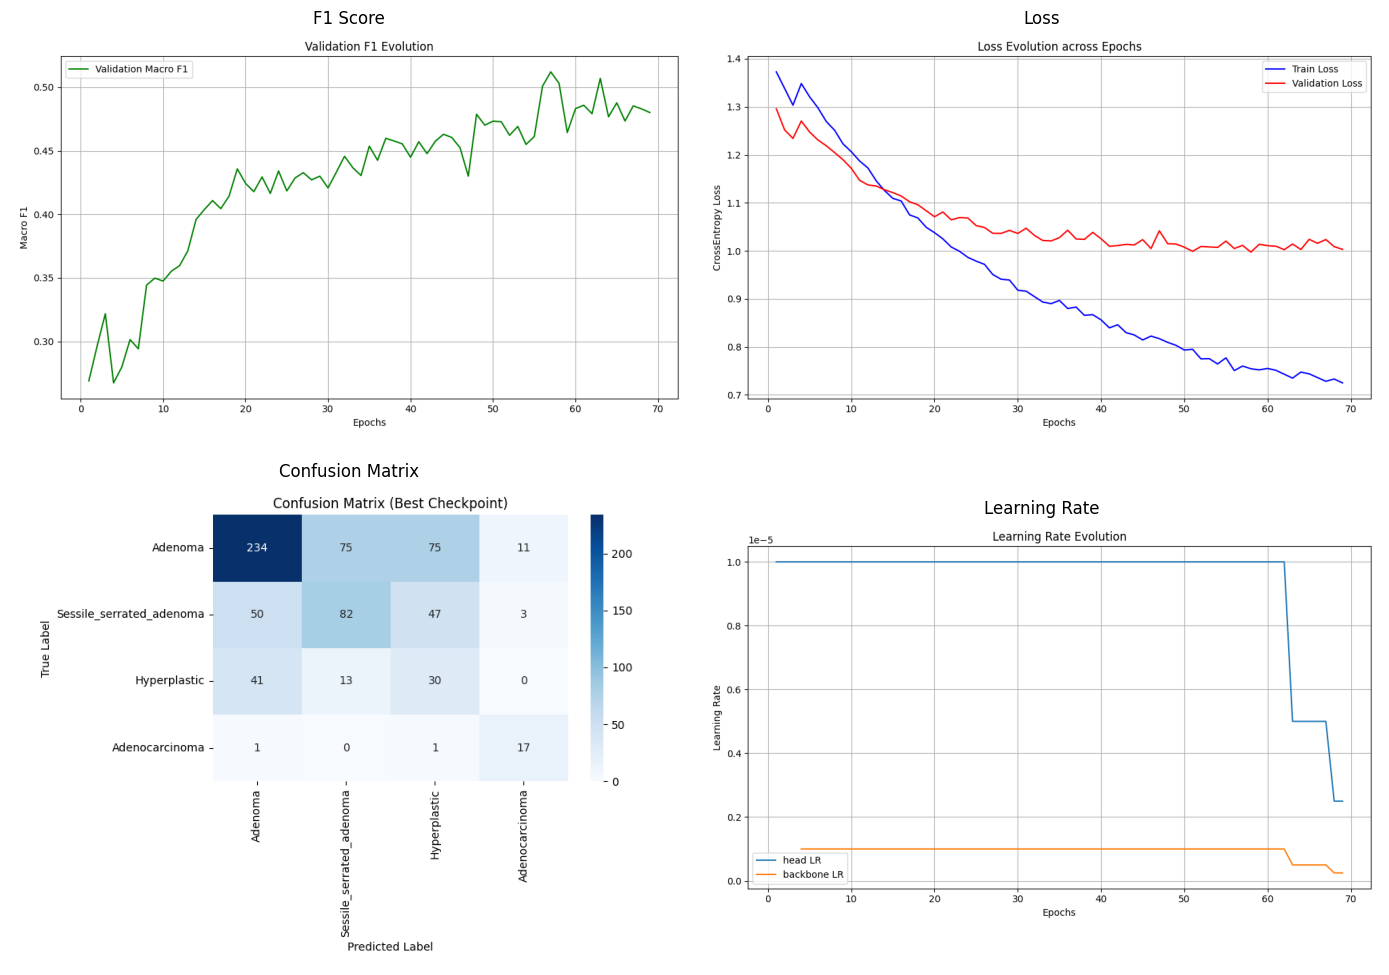

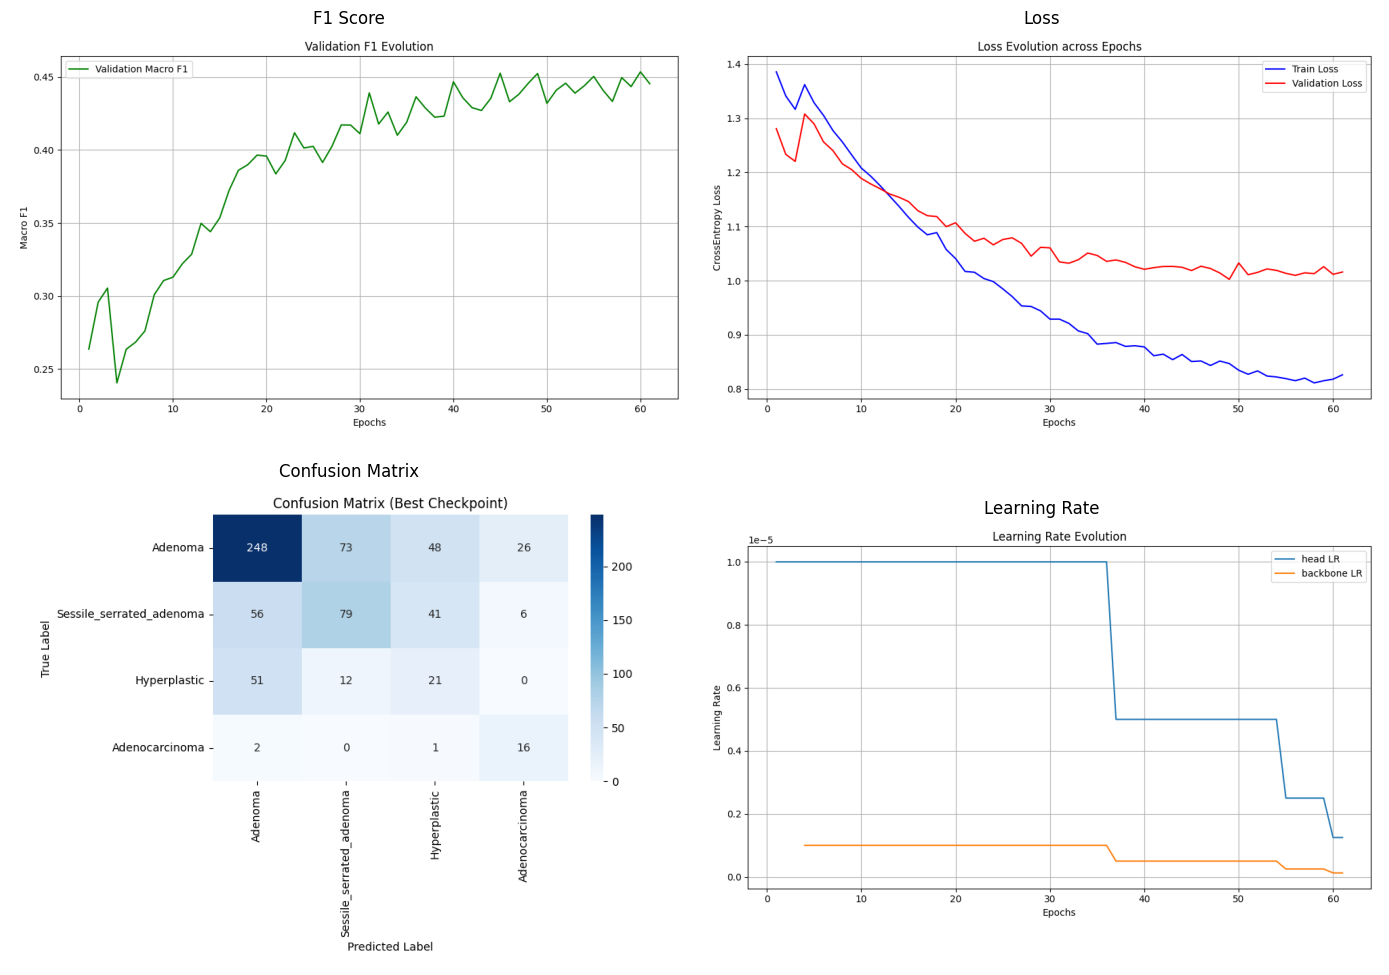

In [11]:
show_phase3_plots(
    train_csv=phase3_result["output_csv"],
    descriptor=phase3_result["descriptor"],
    training_config=TRAINING_CONFIG,
)

In [12]:
print_phase3_summary(
    train_csv=phase3_result["output_csv"],
    descriptor=phase3_result["descriptor"],
    training_config=TRAINING_CONFIG,
)

accuracy: mean=0.5415, std=0.0108
balanced_accuracy: mean=0.5651, std=0.0180
macro_f1: mean=0.4900, std=0.0296
weighted_f1: mean=0.5542, std=0.0087
Adenoma_precision: mean=0.7093, std=0.0130
Adenoma_recall: mean=0.6209, std=0.0246
Adenoma_f1-score: mean=0.6618, std=0.0109
Sessile_serrated_adenoma_precision: mean=0.4857, std=0.0144
Sessile_serrated_adenoma_recall: mean=0.4519, std=0.0158
Sessile_serrated_adenoma_f1-score: mean=0.4680, std=0.0088
Hyperplastic_precision: mean=0.1863, std=0.0088
Hyperplastic_recall: mean=0.2798, std=0.0519
Hyperplastic_f1-score: mean=0.2228, std=0.0208
Adenocarcinoma_precision: mean=0.4614, std=0.1047
Adenocarcinoma_recall: mean=0.9079, std=0.0504
Adenocarcinoma_f1-score: mean=0.6076, std=0.1001
macro_avg_precision: mean=0.4607, std=0.0300
macro_avg_recall: mean=0.5651, std=0.0180
macro_avg_f1-score: mean=0.4900, std=0.0296
weighted_avg_precision: mean=0.5779, std=0.0089
weighted_avg_recall: mean=0.5415, std=0.0108
weighted_avg_f1-score: mean=0.5542, std=0